In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 7.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
dtype = torch.float64
torch.set_default_dtype(dtype)

Using device: cpu


In [ ]:
#@title GT functions

def f1(x, A=1.0, tau=1.6, offset=0.05):
    """
    Monotonic increasing function with saturation.
    """
    return offset + A * (1.0 - np.exp(-x / tau))

def f2(x, L=1.0, x0=2.5, k=3.0, offset=0.05):
    """
    Sigmoid-like transition.
    """
    return offset + L / (1 + np.exp(-k * (x - x0)))

def f3(x, x0=2.5, gamma=0.25, A=1.0, offset=0.05):
    """
    Lorentzian resonance peak.
    """
    return offset + A * gamma**2 / ((x - x0)**2 + gamma**2)

def f4(x, A=1.0, gamma=0.35, w=4.0, offset=0.0):
    """
    Damped oscillatory response.
    """
    return offset + A * np.exp(-gamma * x) * np.cos(w * x)

In [ ]:
#@title auxilary functions

def generate_experiment_data(f_true, x_grid, n_points=9, noise_std=0.05, seed=None, plot=True):
    """
    Generate sparse noisy experimental observations from a ground truth function.

    Parameters
    ----------
    f_true : function
        Ground truth function f(x)
    x_grid : array
        Dense grid of x values
    n_train : int
        Number of experimental points
    noise_std : float
        Standard deviation of Gaussian noise
    seed : int or None
        Random seed for reproducibility
    plot : bool
        Whether to visualize the data

    Returns
    -------
    x_train, y_train
    """

    if seed is not None:
        np.random.seed(seed)

    idx = np.sort(np.random.choice(np.arange(len(x_grid)), size=n_points, replace=False))
    x_train = x_grid[idx]
    y_train = f_true(x_train) + np.random.normal(0, noise_std, size=n_points)

    if plot:
        plt.figure(figsize=(7,4))
        plt.plot(x_grid, f_true(x_grid), label="True function")
        plt.scatter(x_train, y_train, color="red", s=60, label="Observed points", zorder=3)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

    return x_train, y_train

In [ ]:
#@title GP model

class ExactGPModel(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood, covar_module):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = covar_module#

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=200, plot=True):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if plot:
        plt.figure(figsize=(6, 3))
        plt.plot(losses)
        plt.xlabel("Iteration")
        plt.ylabel("Negative log marginal likelihood")
        plt.title("Training loss")
        plt.show()

    return losses

# Hackathon Task

The objective is to explore an alternative workflow for interpreting sparse experimental data using Gaussian Processes (GP).


Instead of relying solely on the most probable GP prediction (i.e., the posterior mean), we consider the following approach:

1. Fit a GP model to a small set of noisy observations.
2. Draw multiple candidate functions from the GP posterior (Thompson-style sampling).
3. Treat these sampled functions as plausible hypotheses consistent with the data.
4. Select the final candidate based on external criteria such as known physics, constraints, or expected qualitative behavior.


In this notebook we implement the first three steps of this workflow.
The goal of the hackathon is to develop possible realizations of Step 4:
designing criteria or algorithms for ranking and selecting the most meaningful prediction from the GP posterior.


**Please, do not forget to submit your result. A short YouTube tutorial from Utkarsh explaining how to submit your results:**
https://www.youtube.com/watch?v=QcwQkAocrDY&t=35s

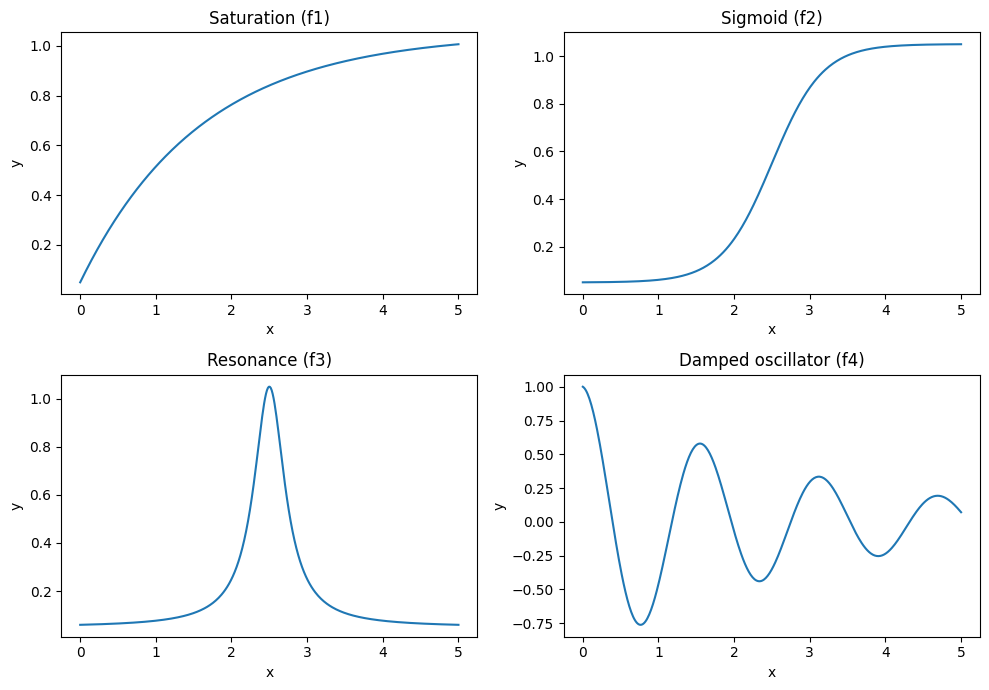

In [ ]:
x_grid = np.linspace(0.0, 5.0, 400)
y1 = f1(x_grid)
y2 = f2(x_grid)
y3 = f3(x_grid)
y4 = f4(x_grid)

fig, ax = plt.subplots(2,2, figsize = (10,7))

for ax_ ,yy in zip(ax.flatten(), [y1, y2, y3, y4]):
  ax_.plot(x_grid, yy)
  ax_.set_xlabel("x")
  ax_.set_ylabel("y")

for ax_ ,ttl in zip(ax.flatten(), ['Saturation (f1)', 'Sigmoid (f2)', 'Resonance (f3)', 'Damped oscillator (f4)']):
  ax_.set_title(ttl)

plt.tight_layout()
# plt.show()

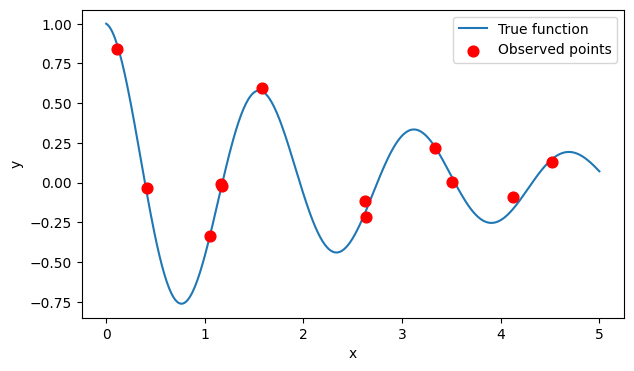

In [ ]:
#choose function
f= f4

x_exp, y_exp = generate_experiment_data(f, x_grid, n_points=12, noise_std=0.05, seed=42)

#converting to torch.tensor
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

In [ ]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
likelihood.noise = 1e-1

covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5))
        )
model = ExactGPModel(train_x, train_y, likelihood, covar_module = covar_module)

model = model.to(device=device, dtype=dtype)
likelihood = likelihood.to(device=device, dtype=dtype)



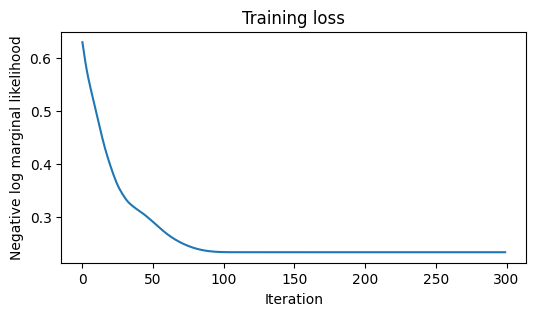

In [ ]:
losses = train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=300, plot=True)

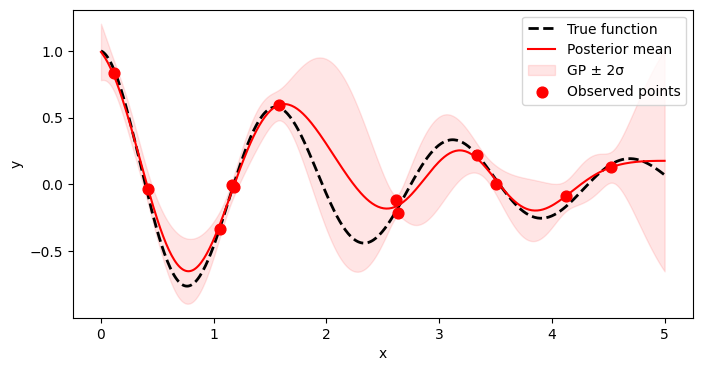

In [ ]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_grid, f(x_grid), 'k--', label="True function", linewidth=2)
plt.plot(x_grid, pred_mean, 'r',label="Posterior mean", linestyle="-")
plt.fill_between(
    x_grid,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.1,
    label="GP ± 2σ",
    color='r'
)
plt.scatter(x_exp, y_exp, color="red", s=60, label="Observed points", zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
#Tompson sampling

n_candidates = 64 #number of the cundidate functions

with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

samples_np = samples.cpu().numpy() # - candidate function

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


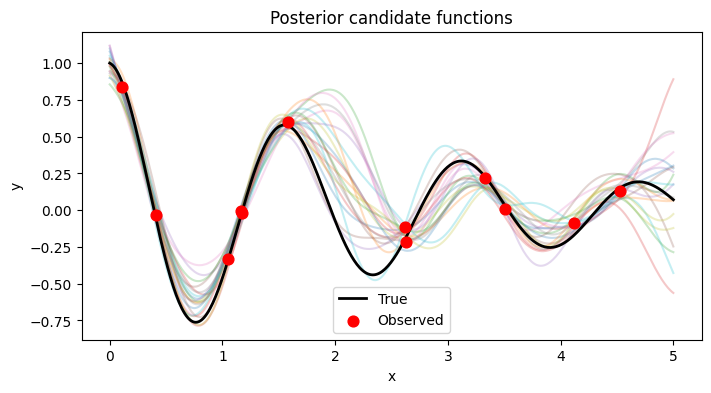

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates, 20)):
    plt.plot(x_grid, samples_np[i], alpha=0.25)

plt.plot(x_grid, f(x_grid), color="black", linewidth=2, label="True")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

# Can we design criteria or algorithms for ranking and selecting the most meaningful candidate function?

In [ ]:
!pip install -U pysr

In [ ]:
from pysr import PySRRegressor

**Level 1 — simplest: symbolic screening of posterior candidates Goal**

Use PySR to fit functions sampled from the GP posterior, then rank them by how well their symbolic form matches prior physical expectations.

Workflow

 - Fit GP to sparse data.

- Sample multiple posterior candidate functions.

- Fit each candidate with PySR.

- Analyze the discovered symbolic expressions.

- Select candidates whose symbolic structure is physically meaningful.

For a damped oscillator:

- preferred expressions should contain sin, cos, or oscillatory structure,

- possibly also an exponential decay term.

Output

- top posterior candidates,

- corresponding symbolic expressions,

- rule-based ranking based on expected physical structure.

In [ ]:
# you code

In [ ]:
model_sr = PySRRegressor(
    niterations=50,
    populations=11,
    population_size=20,
    model_selection="best",
    loss="loss(prediction, target) = (prediction - target)^2",

    binary_operators=["+", "-", "*", "/"],

    unary_operators=[
        "sin",
        "exp",
        "cos"
    ],

    maxsize=10,
    maxdepth=10,

    parsimony=2e-3,

    verbosity=0,
)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(


In [ ]:
flgs = []
equations = []

for i in range(len(samples_np)):
  print(i)
  model_sr.fit(x_grid.reshape(-1, 1), samples_np[i])
  best_eq = model_sr.get_best()["equation"]
  equations.append(best_eq)
  has_harmonic = ("sin" in best_eq) or ("cos" in best_eq)
  flgs.append(has_harmonic)



0


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


1


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


2


...

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


62


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


63


/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2217: UserWarning: The discovered expressions are being reset. Please set `warm_start=True` if you wish to continue to start a search where you left off.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


In [ ]:
print(f'Harmonic candidates: ', float(np.sum(np.array(flgs))/len(flgs)*100), '%')

Harmonic candidates:  96.875 %


In [ ]:

best_eq = model_sr.get_best()["equation"]
has_harmonic = ("sin" in best_eq) or ("cos" in best_eq)

print(best_eq)
print("Harmonic:", has_harmonic)

cos(x0 / -0.2514652) * 0.42101663
Harmonic: True


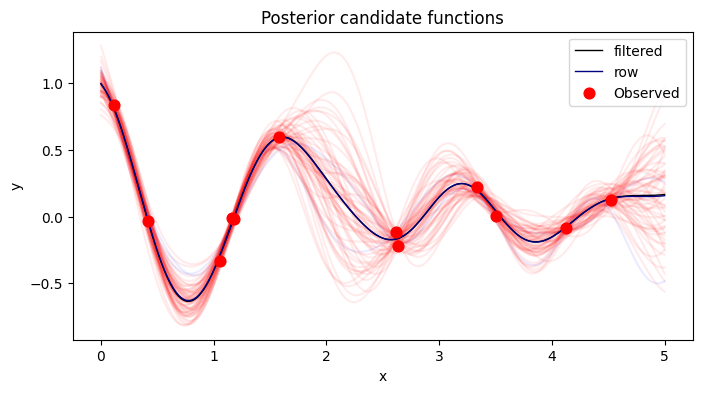

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(min(n_candidates,70)):
  if flgs[i]:
    c='r'
  else:
    c='b'
  plt.plot(x_grid, samples_np[i], alpha=0.08, c=c)

#plt.plot(x_grid, f(x_grid), '--', color="black", linewidth=1, label="True")
plt.plot(x_grid, samples_np[flgs].mean(0), '-', color="black", linewidth=1, label="filtered")
plt.plot(x_grid, samples_np.mean(0), '-', color="navy", linewidth=1, label="row")
plt.scatter(x_exp, y_exp, color="red", s=60, zorder=3, label="Observed")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Posterior candidate functions")
plt.legend()
plt.show()

In [ ]:
equations

['cos(x0 * 3.9302375) * 0.37208822',
 'cos(x0 * -0.42063615) * sin(cos(x0 / -0.27706948))',
 'sin(exp((1.9569969 - x0) * (x0 + 0.33049825)))',
 'cos(x0 / 0.2586539) / exp(x0)',
 'exp(x0 * -5.181445)',
 '0.8637458 - cos(cos(x0 / -0.49165717))',
 'sin(exp(cos(x0 + -0.7371946) * 1.1603246)) + -0.32657298',
 'cos(x0 / 0.26162255) * 0.37593254',
 'sin(exp(x0 * ((x0 + -1.6799331) * -1.9687018)))',
 'cos(x0 / 0.2777161) / exp(x0)',
 'exp(x0 * ((1.0158117 - sin(x0)) * -16.320496))',
 'cos(x0 / -0.2587045) * exp(x0 * -0.41361564)',
 'cos((x0 + sin(x0)) * 2.421189) * 0.3987011',
 'cos(x0 * 3.87604) / (x0 + 0.8540243)',
 'cos(sin(x0 + x0)) + -0.6793362',
 'cos((x0 + x0) * 1.9617851) / (x0 + 0.86280763)',
 '-0.6060786 + cos(sin(x0 * 1.9120231))',
 'sin(sin(exp(cos(x0) * 2.0710666)) * 0.4802123)',
 'sin((x0 + -0.42545423) / 0.25786442) * -0.3219995',
 'sin((0.3169199 - sin(x0)) / -0.18801954) * -0.44072214',
 'cos(x0 / -0.26021266) / (x0 + 0.9161481)',
 'sin(cos(x0 * 3.3423169) / exp(x0))',
 'sin(e

# most common symbolic motif

In [ ]:
from collections import Counter

def extract_symbolic_features(expr):
    e = expr.replace(" ", "")

    has_sin = ("sin(" in e) or ("cos(" in e)
    has_exp = "exp(" in e
    has_div = "/" in e
    has_x = "x0" in e
    has_x2 = ("x0*x0" in e) or ("(x0*x0)" in e) or ("square(x0)" in e)

    # weak heuristic: linear / affine if x0 appears but no trig/exp/div
    linear_like = has_x and (not has_sin) and (not has_exp) and (not has_div)

    # trend + oscillation
    harmonic_trend = has_sin and has_x

    return {
        "harmonic": has_sin,
        "exp": has_exp,
        "rational": has_div,
        "linear": linear_like,
        "quadratic": has_x2,
        "harmonic_trend": harmonic_trend,
        "damped_harmonic": has_sin and has_exp,
    }


def summarize_symbolic_features(expressions):
    counts = Counter()

    for expr in expressions:
        feats = extract_symbolic_features(expr)
        for k, v in feats.items():
            if v:
                counts[k] += 1

    n = len(expressions)
    freqs = {k: counts[k] / n for k in [
        "harmonic",
        "exp",
        "rational",
        "linear",
        "quadratic",
        "harmonic_trend",
        "damped_harmonic",
    ]}

    return counts, freqs

In [ ]:
import gpytorch

def design_kernel_from_symbolic_counts(counts, n_total):
    """
    Design a GP kernel based on symbolic motif counts.

    Parameters
    ----------
    counts : dict-like
        Counts of motifs, e.g. from summarize_symbolic_features
    n_total : int
        Total number of expressions

    Returns
    -------
    result : dict
        {
            "kernel_name": ...,
            "kernel": ...,
            "reason": ...,
            "frequencies": ...
        }
    """
    # Frequencies
    harmonic_freq = counts.get("harmonic", 0) / n_total
    exp_freq = counts.get("exp", 0) / n_total
    linear_freq = counts.get("linear", 0) / n_total
    harmonic_trend_freq = counts.get("harmonic_trend", 0) / n_total
    damped_harmonic_freq = counts.get("damped_harmonic", 0) / n_total
    rational_freq = counts.get("rational", 0) / n_total

    freqs = {
        "harmonic": harmonic_freq,
        "exp": exp_freq,
        "linear": linear_freq,
        "harmonic_trend": harmonic_trend_freq,
        "damped_harmonic": damped_harmonic_freq,
        "rational": rational_freq,
    }

    # Rule 1: damped harmonic dominates
    if (harmonic_freq > 0.35) and ((exp_freq > 0.15) or (damped_harmonic_freq > 0.10)):
        if linear_freq > 0.20 or harmonic_trend_freq > 0.20:
            kernel = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.LinearKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5)) +
                (gpytorch.kernels.PeriodicKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5)) * gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5)))
            )
            kernel_name = "Linear + (Periodic * RBF)"
            reason = (
                "Many symbolic expressions contain harmonic structure, and a non-negligible "
                "fraction also contain exponential terms, suggesting damped oscillations. "
                "A linear component is added because trend-like expressions are also common."
            )
        else:
            kernel = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.PeriodicKernel() * gpytorch.kernels.RBFKernel()
            )
            kernel_name = "Periodic * RBF"
            reason = (
                "Harmonic structure is frequent and exponential terms appear often enough "
                "to suggest damped oscillations. The product kernel captures oscillations "
                "with decaying correlation."
            )

    # Rule 2: harmonic structure dominates, but damping is weak
    elif harmonic_freq > 0.35:
        if linear_freq > 0.20 or harmonic_trend_freq > 0.20:
            kernel = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.LinearKernel() +
                gpytorch.kernels.PeriodicKernel() +
                gpytorch.kernels.RBFKernel()
            )
            kernel_name = "Linear + Periodic + RBF"
            reason = (
                "Harmonic symbolic forms are dominant, while some expressions also indicate "
                "a trend. The additive structure allows separate modeling of trend, periodicity, "
                "and smooth residual variation."
            )
        else:
            kernel = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.PeriodicKernel() + gpytorch.kernels.RBFKernel()
            )
            kernel_name = "Periodic + RBF"
            reason = (
                "Harmonic structure is dominant, but damping is not strong enough to require "
                "a multiplicative kernel. The additive form captures oscillation plus smooth deviation."
            )

    # Rule 3: mostly smooth trend / linear-like
    elif linear_freq > 0.30:
        kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.LinearKernel() + gpytorch.kernels.RBFKernel()
        )
        kernel_name = "Linear + RBF"
        reason = (
            "Symbolic expressions are frequently linear or affine, suggesting a global trend "
            "plus smooth nonlinear correction."
        )

    # Rule 4: many rational or odd forms, but no strong motif
    elif rational_freq > 0.25:
        kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5)
        )
        kernel_name = "Matern(ν=2.5)"
        reason = (
            "Many expressions are rational or structurally mixed, without a dominant interpretable "
            "motif. A Matern kernel is a robust fallback for moderately rough functions."
        )

    # Default: smooth generic behavior
    else:
        kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )
        kernel_name = "RBF"
        reason = (
            "No strong symbolic motif dominates the posterior candidate fits, so a smooth generic "
            "kernel is used as the default."
        )

    return {
        "kernel_name": kernel_name,
        "kernel": kernel,
        "reason": reason,
        "frequencies": freqs,
    }

In [ ]:
counts, freqs = summarize_symbolic_features(equations)

print("Counts:")
print(counts)

print("\nFrequencies:")
print(freqs)

kernel_info = design_kernel_from_symbolic_counts(counts, len(equations))

print("\nSuggested kernel:")
print(kernel_info["kernel_name"])

print("\nReason:")
print(kernel_info["reason"])

kernel = kernel_info["kernel"]

Counts:
Counter({'harmonic': 62, 'harmonic_trend': 62, 'rational': 37, 'exp': 28, 'damped_harmonic': 26})

Frequencies:
{'harmonic': 0.96875, 'exp': 0.4375, 'rational': 0.578125, 'linear': 0.0, 'quadratic': 0.0, 'harmonic_trend': 0.96875, 'damped_harmonic': 0.40625}

Suggested kernel:
Linear + (Periodic * RBF)

Reason:
Many symbolic expressions contain harmonic structure, and a non-negligible fraction also contain exponential terms, suggesting damped oscillations. A linear component is added because trend-like expressions are also common.


In [ ]:
kernel

ScaleKernel(
  (base_kernel): AdditiveKernel(
    (kernels): ModuleList(
      (0): LinearKernel(
        (raw_variance_constraint): Positive()
      )
      (1): ProductKernel(
        (kernels): ModuleList(
          (0): PeriodicKernel(
            (lengthscale_prior): LogNormalPrior()
            (raw_lengthscale_constraint): Positive()
            (raw_period_length_constraint): Positive()
          )
          (1): RBFKernel(
            (lengthscale_prior): LogNormalPrior()
            (raw_lengthscale_constraint): Positive()
          )
        )
      )
    )
  )
  (raw_outputscale_constraint): Positive()
)

In [ ]:
model = ExactGPModel(train_x, train_y, likelihood, covar_module = kernel)

model = model.to(device=device, dtype=dtype)
likelihood = likelihood.to(device=device, dtype=dtype)

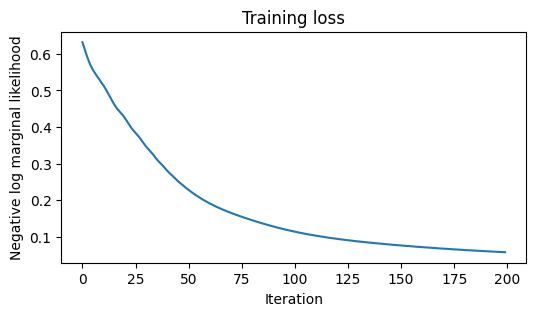

In [ ]:
losses = train_gp(model, likelihood, train_x, train_y, lr=0.02, training_iter=200, plot=True)

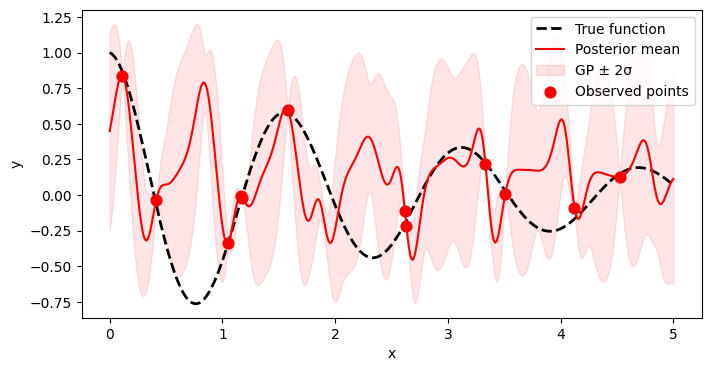

In [ ]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(x_grid, f(x_grid), 'k--', label="True function", linewidth=2)
plt.plot(x_grid, pred_mean, 'r',label="Posterior mean", linestyle="-")
plt.fill_between(
    x_grid,
    pred_mean - 2 * pred_std,
    pred_mean + 2 * pred_std,
    alpha=0.1,
    label="GP ± 2σ",
    color='r'
)
plt.scatter(x_exp, y_exp, color="red", s=60, label="Observed points", zorder=3)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
next_point = np.argmax(pred_std)

In [ ]:
n_iter = 10
n_candidates = 15

kernels = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5))
        )

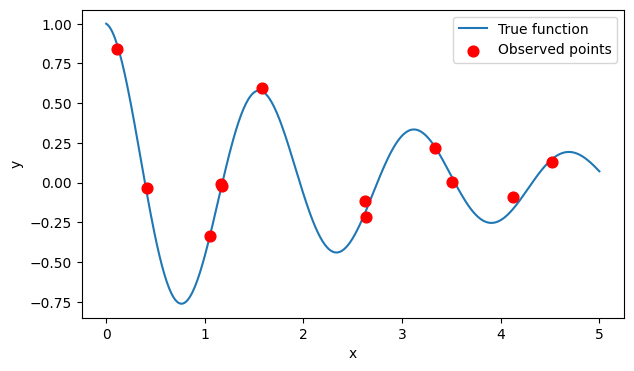

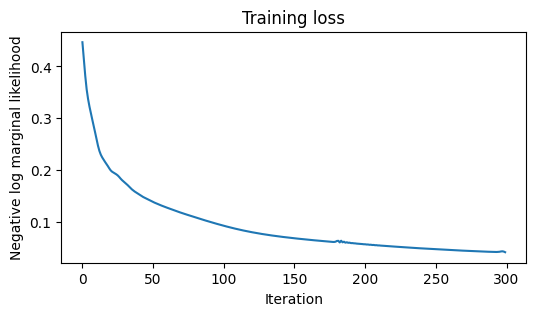

RuntimeError: You must train on the training inputs!

In [ ]:
f= f4

x_exp, y_exp = generate_experiment_data(f, x_grid, n_points=12, noise_std=0.05, seed=42)

#converting to torch.tensor
train_x = torch.tensor(x_exp, dtype=dtype, device=device).unsqueeze(-1)
train_y = torch.tensor(y_exp, dtype=dtype, device=device)

test_x = torch.tensor(x_grid, dtype=dtype, device=device).unsqueeze(-1)

covar_module = gpytorch.kernels.ScaleKernel(
              gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.LogNormalPrior(0.0, 0.5))
          )


for i in range(n_iter):

  likelihood = gpytorch.likelihoods.GaussianLikelihood()
  likelihood.noise = 1e-1

  model = ExactGPModel(train_x, train_y, likelihood, covar_module = kernel)

  model = model.to(device=device, dtype=dtype)
  likelihood = likelihood.to(device=device, dtype=dtype)

  losses = train_gp(model, likelihood, train_x, train_y, lr=0.05, training_iter=300, plot=True)

  with torch.no_grad():
    posterior = model(test_x)
    samples = posterior.sample(torch.Size([n_candidates]))

  samples_np = samples.cpu().numpy()

  flgs = []
  equations = []

  for i in range(len(samples_np)):
    print(i)
    model_sr.fit(x_grid.reshape(-1, 1), samples_np[i])
    best_eq = model_sr.get_best()["equation"]
    equations.append(best_eq)
    has_harmonic = ("sin" in best_eq) or ("cos" in best_eq)
    flgs.append(has_harmonic)

  counts, freqs = summarize_symbolic_features(equations)

  print("Counts:")
  print(counts)

  print("\nFrequencies:")
  print(freqs)

  kernel_info = design_kernel_from_symbolic_counts(counts, len(equations))

  print("\nSuggested kernel:")
  print(kernel_info["kernel_name"])

  print("\nReason:")
  print(kernel_info["reason"])

  kernel = kernel_info["kernel"]

  with torch.no_grad(), gpytorch.settings.fast_pred_var():
    posterior = model(test_x)
    pred_mean = posterior.mean.cpu().numpy()
    pred_std = posterior.stddev.cpu().numpy()

  train_x = torch.vstack([train_x,test_x[np.argmax(pred_std)]])
  y_next = f(train_x[-1])+ np.random.normal(0, 0.05, size=1)
  y_train = torch.concatenate([train_y, y_next])









In [ ]:
y_next = f(train_x[-1])+ np.random.normal(0, 0.05, size=1)
y_next

/tmp/ipykernel_383/1754928152.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return offset + A * np.exp(-gamma * x) * np.cos(w * x)
/tmp/ipykernel_383/2554384332.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_next = f(train_x[-1])+ np.random.normal(0, 0.05, size=1)


tensor([0.1404])

In [ ]:
torch.concatenate([train_y, y_next])

tensor([ 0.8381, -0.0332, -0.3352, -0.0078, -0.0200,  0.5970, -0.1153, -0.2170,
         0.2189,  0.0055, -0.0877,  0.1279,  0.1404])